In [18]:
from dace_query.sun import Sun

from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime, timedelta

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

## Spectra

In [2]:
# define the path of the directory where dace data is saved
path_dace = '../data/dace_sun/'
direc = 'Jan2017/'  # sub directory where the specific data is
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [3]:
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + direc):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-06', '2017-01-09', '2017-01-10', '2017-01-15', '2017-01-16', '2017-01-18', '2017-01-19', '2017-01-20', '2017-01-21', '2017-01-23', '2017-01-24', '2017-01-25', '2017-01-26']


In [4]:
# make a list of the available files that end by A.fits (s1d)
files_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_ccf_list.extend(files)  # save file names
#files_ccf_list = [s for s in files_ccf_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

s1d files: 294
ccf files: 333


In [187]:
# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('CCF', 'S1D')
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(len(files_ccf), len(files_s1d))

250 250


In [188]:
# activate this cell to use only data from a specific range of dates in January 2017; deactivate it to use the full month
print(files_s1d[221], files_s1d[78])
files_s1d = files_s1d[221:]
files_ccf = files_ccf[221:]

2017-01-25/r.HARPN.2017-01-25T12-00-41.227_S1D_A.fits 2017-01-10/r.HARPN.2017-01-10T14-13-42.904_S1D_A.fits


In [189]:
# check data inside ccf files
hdul = fits.open(path_dace + direc + 'CCF/' + files_ccf[0])

hdr0 = hdul[0].header

for i in list(hdr0):  # variables that include 'RV'
    if 'RV' in i:
        print(i)

print('---------------------------------------')
print(f'Date: {hdr0['DATE-OBS']}')
print(f'Julian date: {hdr0['MJD-OBS']}')

OBSERVAT
TNG RV STEP
TNG RV START
TNG QC BERV
TNG QC BERVMAX
TNG QC CCF RV
TNG QC CCF RV ERROR
---------------------------------------
Date: 2017-01-25T12:00:41.227
Julian date: 57778.5004745373


In [190]:
# extract data from s1d files
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_s1d
spectra = []
err = []
for f in files_s1d:  # iterate over files
    path_file = path_dace + direc + f
    hdul = fits.open(path_file)  # open file
    spectra.append(hdul[1].data['flux'])  # save spectrum
    err.append(hdul[1].data['error'])  # save flux error

spectra = np.array(spectra)
err = np.array(err)

# extract data from ccf files
rv = []
dates = []
julian_dates = []
for f in files_ccf:
    path_file = path_dace + direc + 'CCF/' + f
    hdul = fits.open(path_file)
    hdr0 = hdul[0].header
    rv.append(hdr0['TNG QC CCF RV'])
    dates.append(datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f'))
    julian_dates.append(hdr0['MJD-OBS'])

rv = np.array(rv)
dates = np.array(dates)
julian_dates = np.array(julian_dates)

print(spectra.shape, err.shape, rv.shape, dates.shape, julian_dates.shape)

(29, 212207) (29, 212207) (29,) (29,) (29,)


In [191]:
# extract wavelength (same for all files)
filename = path_dace + direc + files_list[0]
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom

In [192]:
# work only with the Fe I 6173 line
line_min, line_max = 6173, 6173.7
line_indices = np.where((line_min < wl) & (wl < line_max))[0]

wl = wl[line_indices]
spectra = spectra[:, line_indices]

# normalize flux
spectra = np.array([spectra[i] / max(spectra[i]) for i in range(len(spectra))])  # normalize by continuum level

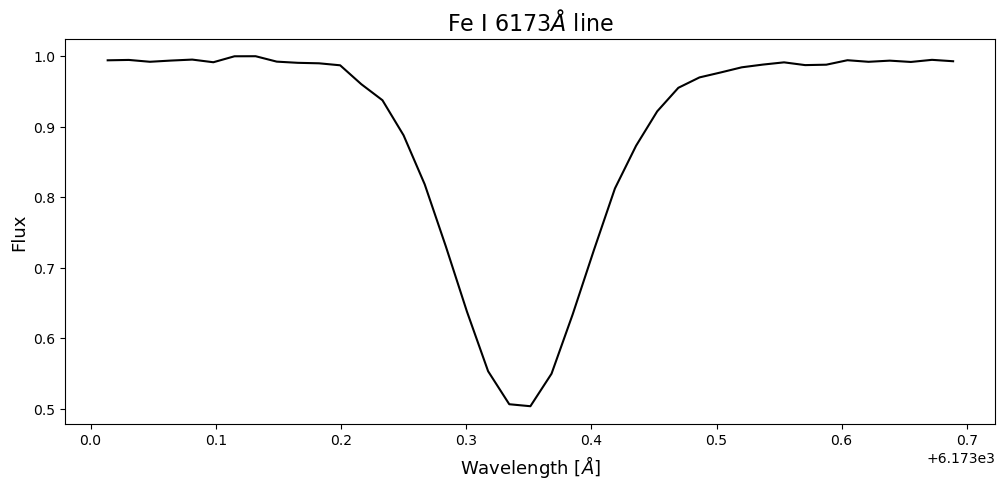

In [193]:
y = spectra[0]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(wl, y, color='k')
ax.set_title(r'Fe I 6173$\AA$ line', size=16)
ax.set_xlabel(r'Wavelength [$\AA$]', size=13)
ax.set_ylabel('Flux', size=13)

plt.show()

In [194]:
# mean spectrum
mean_spec = np.mean(spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
# take out projection over the velocity vector
S_f, D = t.subtract_v(wl, spectra, c=3e8)  # speed of light in m/s

# apply double centering to the spectra matrix
spectra_centered = t.double_centering(S_f)

In [195]:
# calculate mean spectrum and derivatives
d_S0 = np.gradient(mean_spec, wl)  # derivative of the mean spectrum
d2_S0 = np.gradient(d_S0, wl)  # second derivative of the mean spectrum

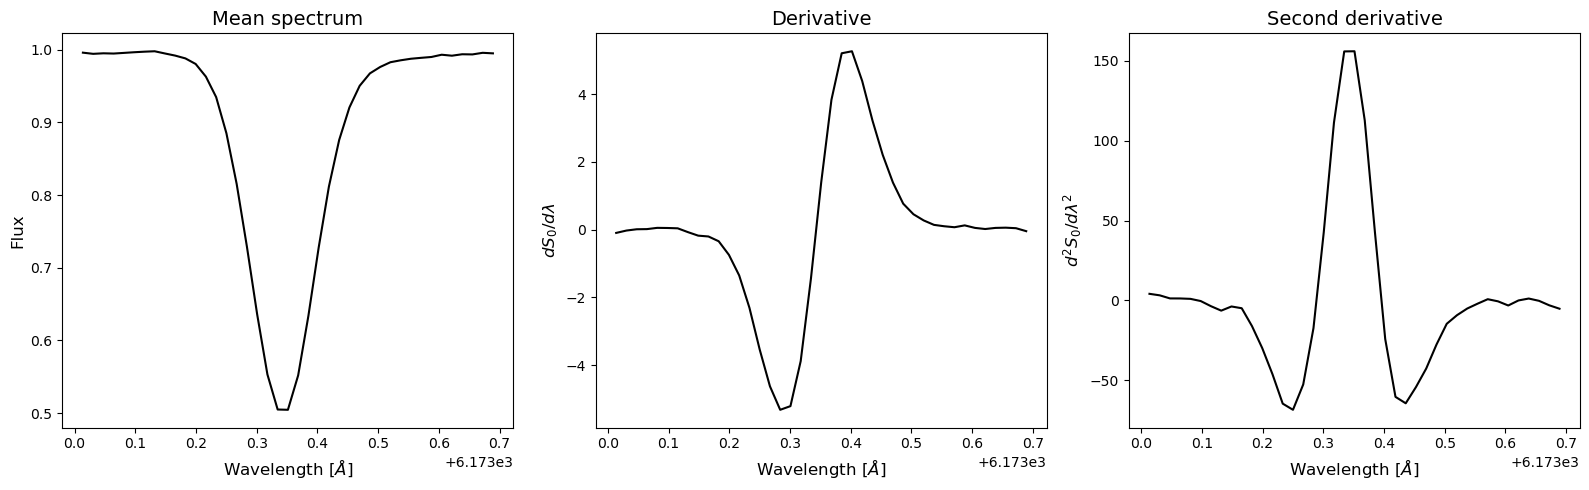

In [196]:
# show mean spectrum and derivatives
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].plot(wl, mean_spec, color='k')
axs[0].set_title('Mean spectrum', size=14)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[0].set_ylabel('Flux', size=12)

axs[1].plot(wl, d_S0, color='k')
axs[1].set_title('Derivative', size=14)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[1].set_ylabel(r'$dS_0 / d\lambda$', size=12)

axs[2].plot(wl, d2_S0, color='k')
axs[2].set_title('Second derivative', size=14)
axs[2].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[2].set_ylabel(r'$d^2S_0 / d\lambda^2$', size=12)

fig.tight_layout()
plt.show()

In [197]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [4.49975657e-01 1.47076898e-01 1.02065211e-01 8.45816076e-02
 5.52150686e-02 3.42291183e-02 2.99882737e-02 2.38482931e-02
 2.21740890e-02 1.34030542e-02 1.24445130e-02 9.00510530e-03
 6.02780419e-03 3.92874526e-03 2.17059767e-03 1.58650579e-03
 9.01476579e-04 5.26850768e-04 4.62351315e-04 1.50897125e-04]


In [198]:
# save loadings and scores
loadings = pca_flux.components_
scores = np.array([pcs[:, i] for i in range(n_components)])

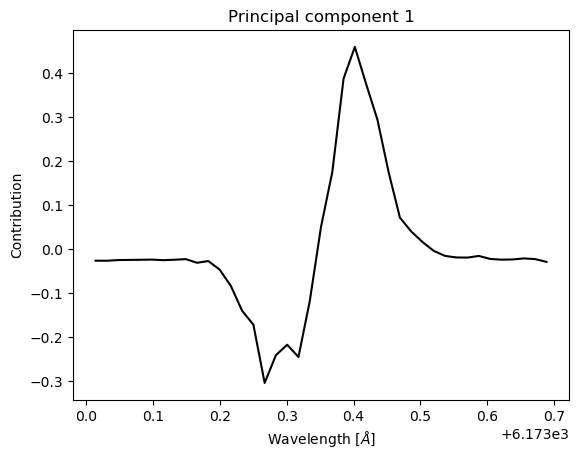

In [199]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, loadings[i], color='k')
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.show()

In [200]:
# Periodograms (Lomb-Scargle because the timestep between observations is irregular)
# https://docs.astropy.org/en/latest/timeseries/lombscargle.html

periodograms = [LombScargle(julian_dates, scores[i]).autopower() for i in range(n_components)]

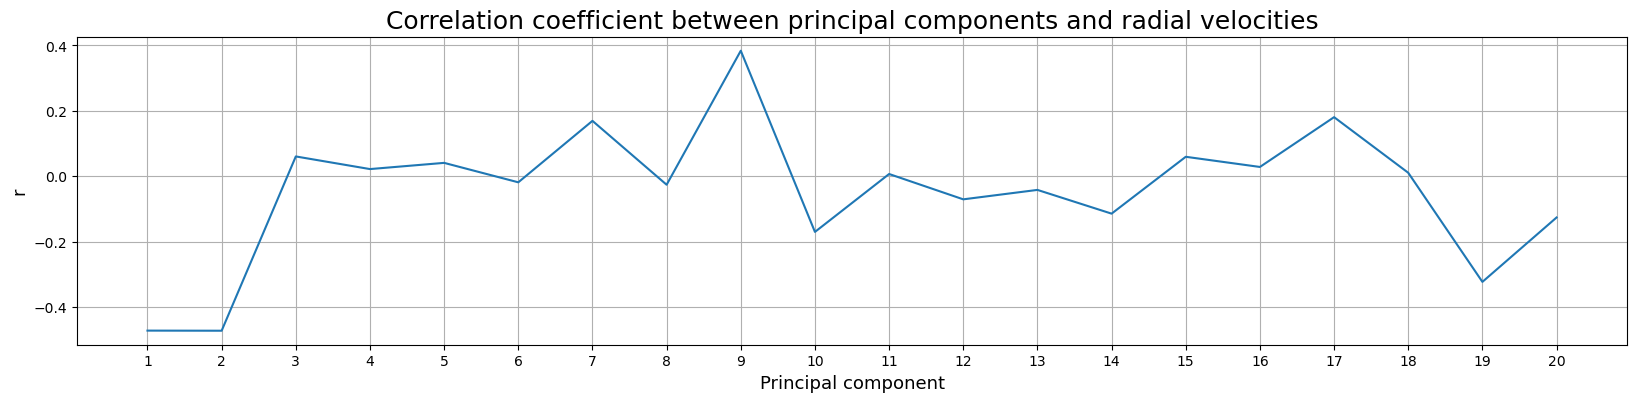

In [201]:
corr = np.array([ss.pearsonr(scores[i], rv)[0] for i in range(n_components)])

fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(np.linspace(1, n_components, n_components), corr)
ax.set_xticks(np.linspace(1, n_components, n_components))
ax.set_title('Correlation coefficient between principal components and radial velocities', size=18)
ax.set_xlabel('Principal component', size=13)
ax.set_ylabel('r', size=13)
ax.grid()
plt.show()

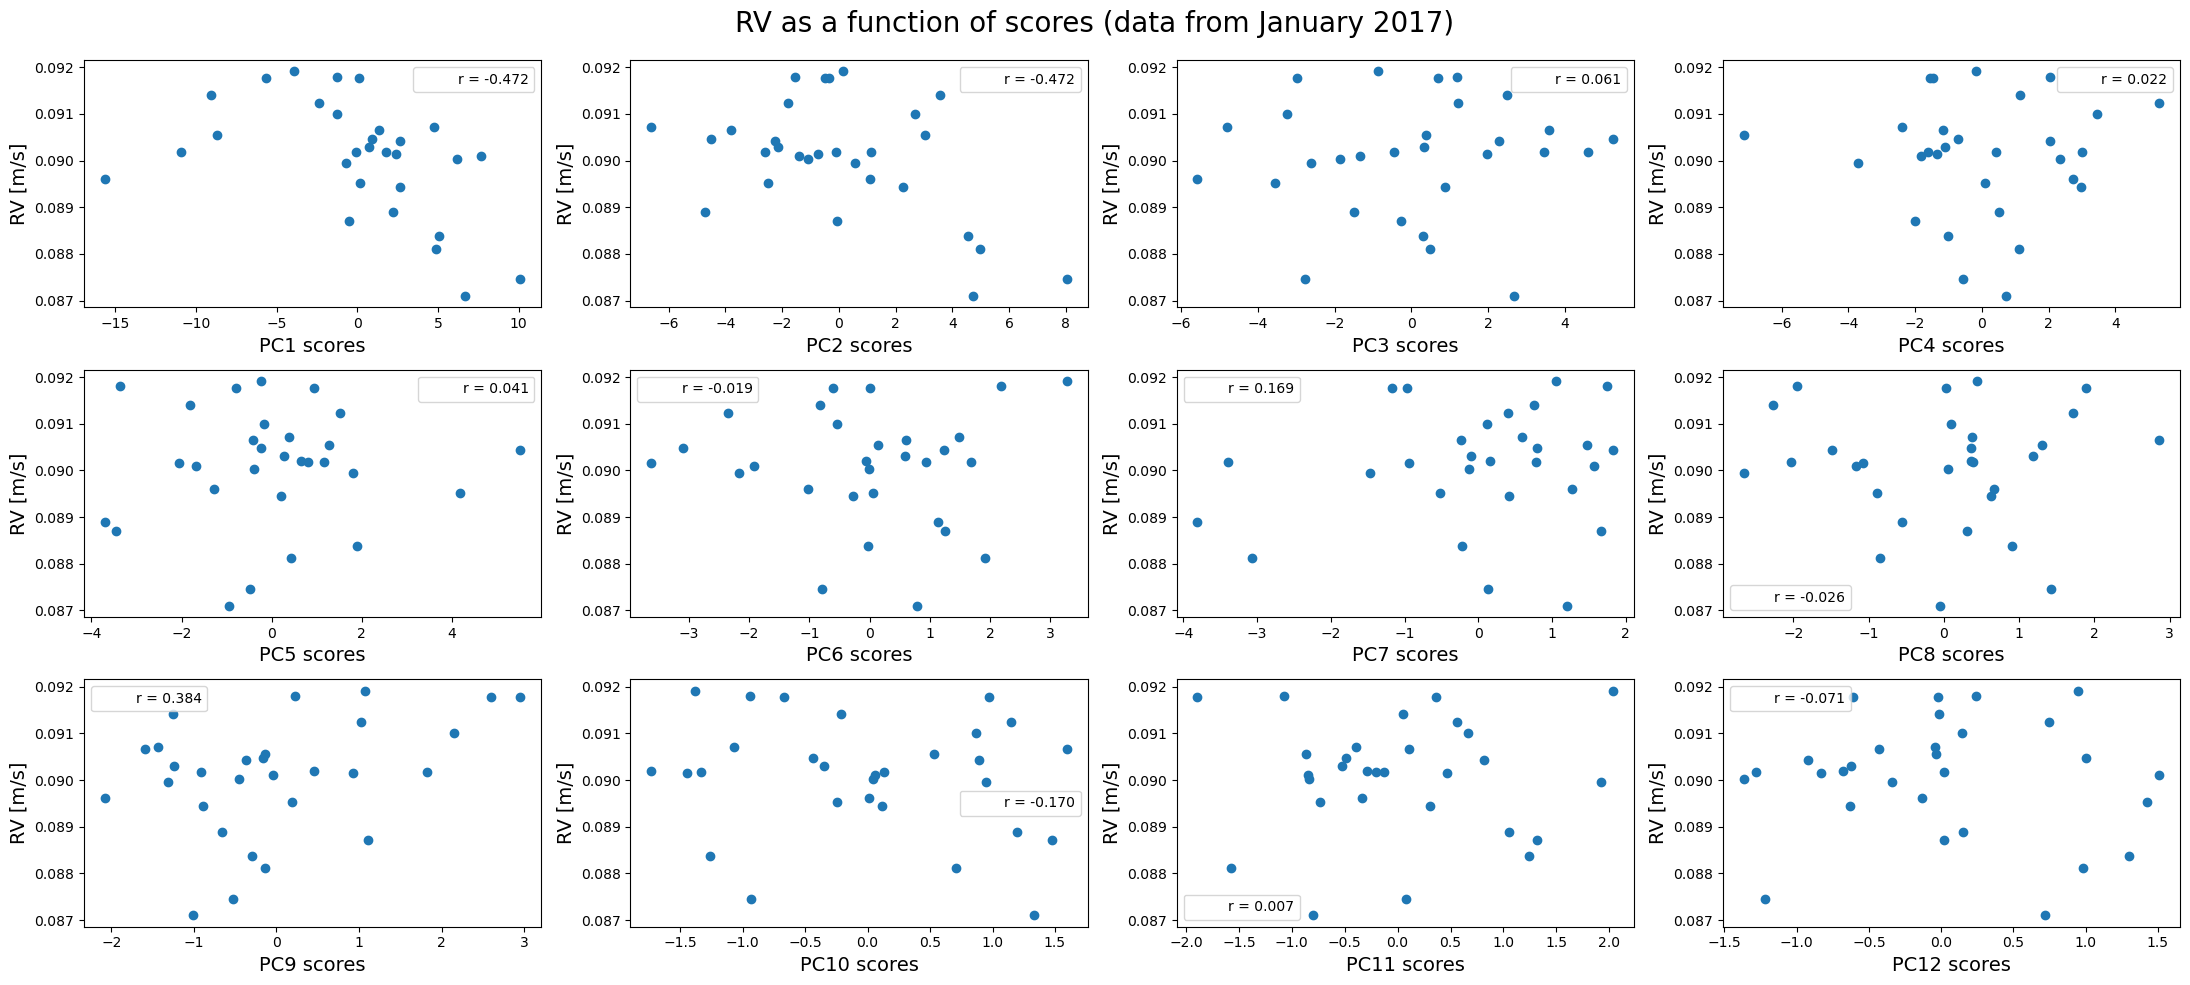

In [202]:
# RV as a function of scores

rows = 3
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(22, 10))
fig.suptitle('RV as a function of scores (data from January 2017)', size=20)

r = -1
k = 0
for i in range(rows*cols):
    if i % cols == 0:
        r += 1  # advance to the next column
        k = 0  # reset row
    # RV as a function of scores
    axs[r][k].scatter(scores[i], rv)
    axs[r][k].axvline(0, color='w', label=f'r = {ss.pearsonr(scores[i], rv)[0]:.3f}', zorder=-1)
    axs[r][k].set_xlabel(f'PC{i+1} scores', size=14)
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    k += 1

fig.tight_layout()
plt.subplots_adjust(top=.93)
plt.show()

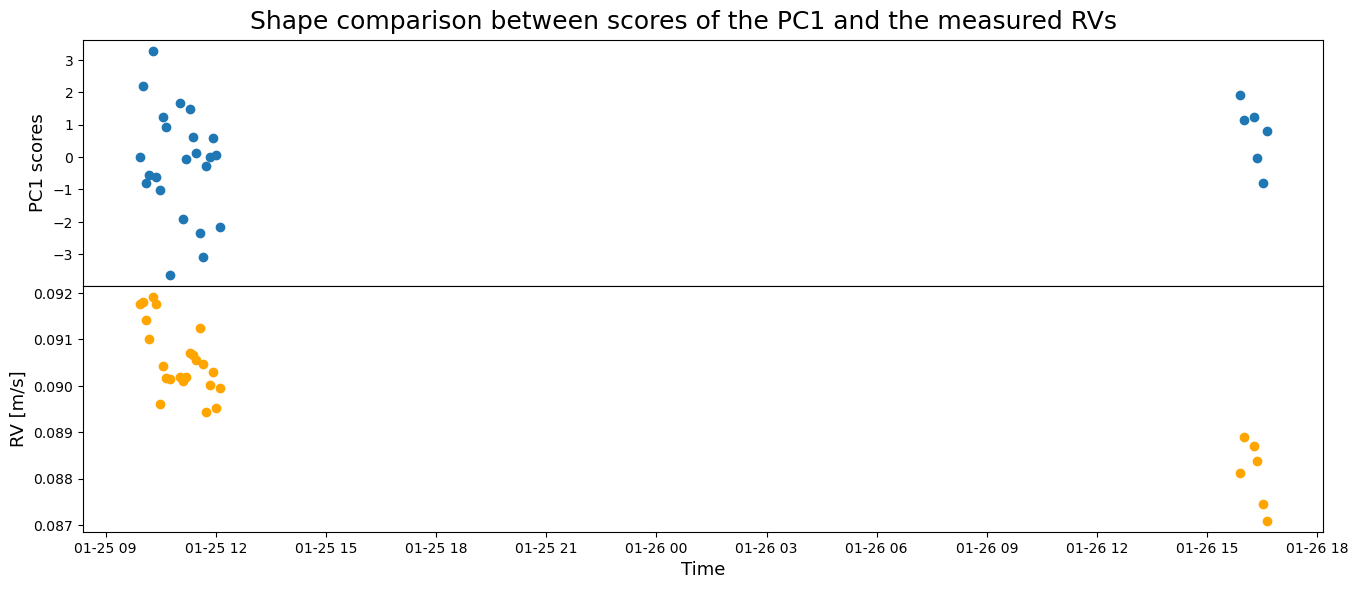

In [203]:
fig, axs = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
fig.suptitle('Shape comparison between scores of the PC1 and the measured RVs', size=18)

axs[0].scatter(dates, scores[5])
axs[0].set_ylabel('PC1 scores', size=13)

axs[1].scatter(dates, rv, color='orange')
axs[1].set_xlabel('Time', size=13)
axs[1].set_ylabel('RV [m/s]', size=13)

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

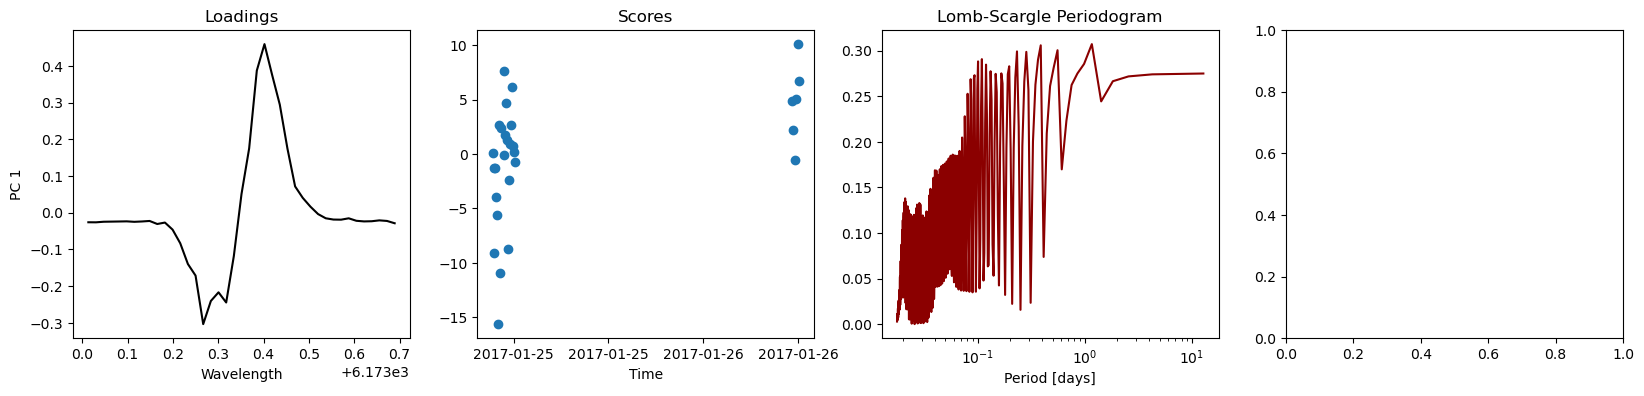

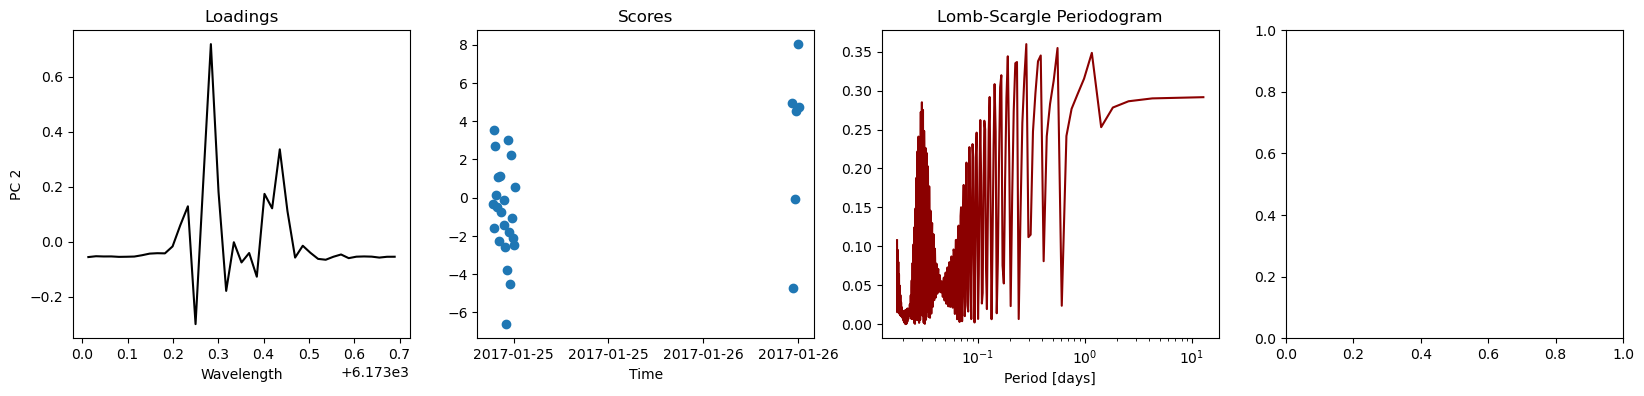

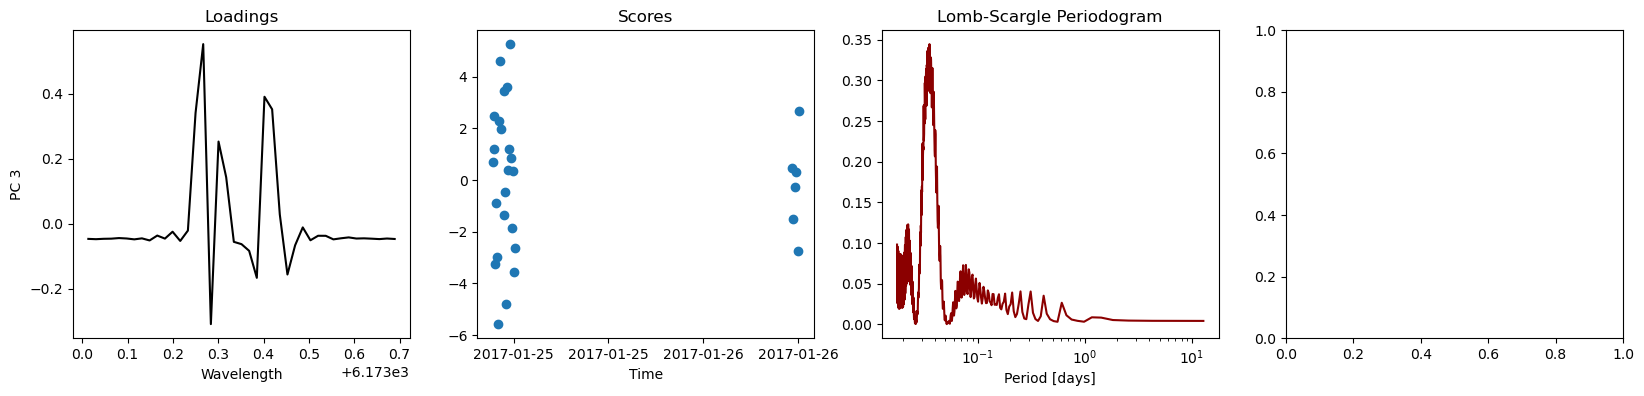

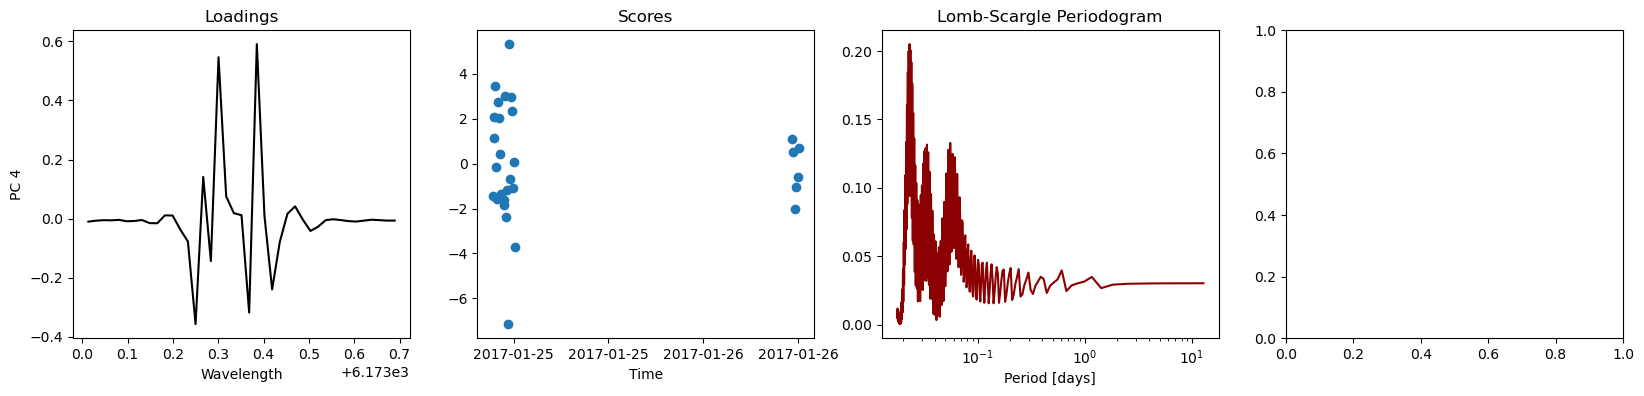

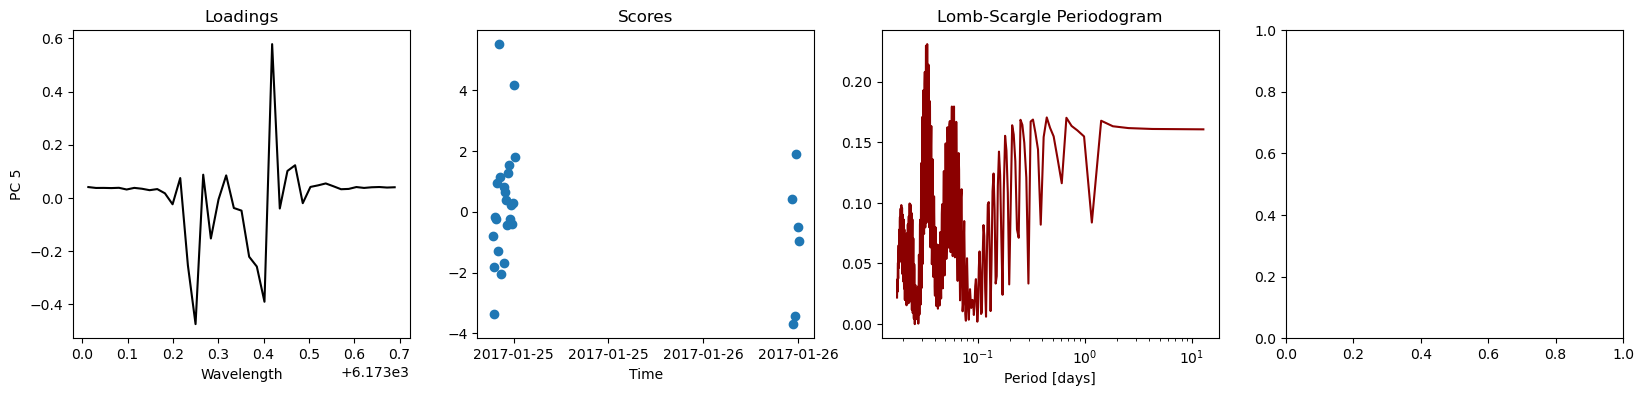

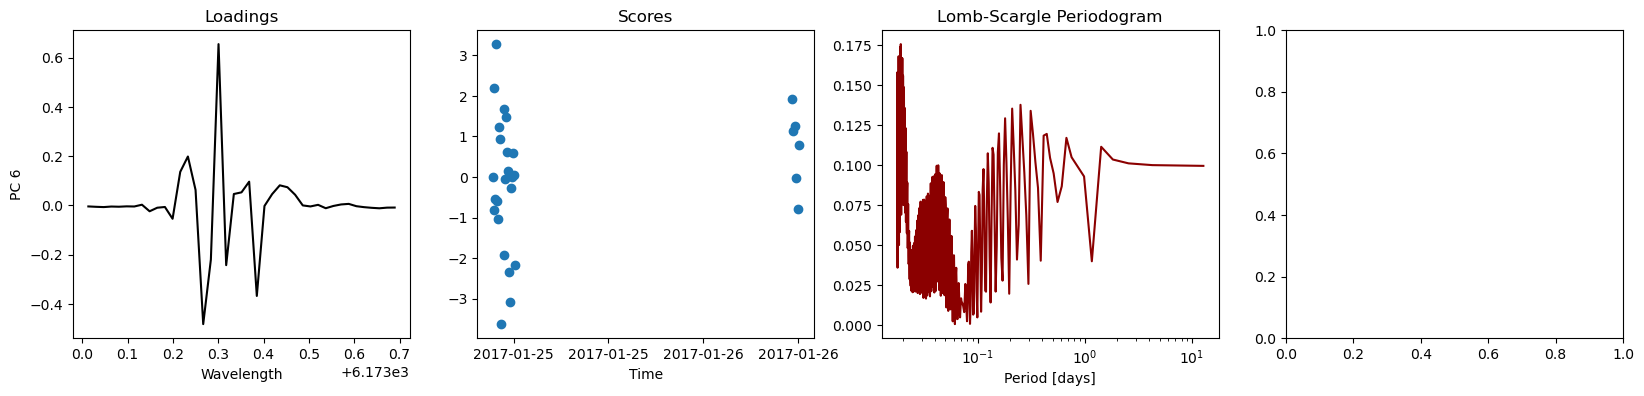

In [204]:
# plot
for i in range(6):
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, loadings[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(dates, scores[i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time')
    axs[1].set_xticks(np.linspace(dates[0], dates[-1], 4))

    # periodogram
    axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Lomb-Scargle Periodogram', size=12)
    axs[2].set_xlabel('Period [days]')
    
    plt.show()